# 06 – Comparación de modelos: Naive Bayes, CART y kNN

## Objetivo

En este notebook se comparan los resultados obtenidos por los tres clasificadores
entrenados sobre el dataset Cora:

- **Naive Bayes** (notebook 03)
- **CART** – árbol de decisión (notebook 04)
- **kNN** – vecinos más cercanos (notebook 05)

Cada modelo fue evaluado en tres escenarios:

1. **Atributos originales** – columnas de palabras de `cora.content`.
2. **Métricas relacionales** – métricas extraídas del grafo de citaciones.
3. **Atributos combinados** – unión de los dos conjuntos anteriores.

Además, cada modelo se optimizó mediante `GridSearchCV`.

## Índice

1. Tabla resumen de resultados
2. Visualización comparativa
3. ¿Sirven las métricas relacionales?
4. ¿Qué aporta combinarlas con las palabras?
5. ¿Qué modelo aprovecha mejor la información relacional?
6. ¿Qué modelo obtiene el mejor accuracy?
7. Conclusiones finales


## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1. Tabla resumen de resultados

Los valores de *accuracy* que se muestran a continuación se obtienen tras la ejecución de los
notebooks 03, 04 y 05. Se recogen aquí de forma centralizada para facilitar la
comparación.


In [2]:
# Naive Bayes (notebook 03)
nb_palabras_base      = 0.758303
nb_palabras_opt       = 0.758303
nb_metricas_base      = 0.752768
nb_metricas_opt       = 0.750923
nb_combinado_base     = 0.806273
nb_combinado_opt      = 0.804428

# CART (notebook 04)
cart_palabras_base    = 0.4649
cart_palabras_opt     = 0.6384
cart_metricas_base    = 0.5646
cart_metricas_opt     = 0.7159
cart_combinado_base   = 0.5240
cart_combinado_opt    = 0.7638

# kNN (notebook 05)
knn_palabras_base     = 0.457565
knn_palabras_opt      = 0.476015
knn_metricas_base     = 0.736162
knn_metricas_opt      = 0.734317
knn_combinado_base    = 0.653137
knn_combinado_opt     = 0.667897


In [3]:
# Construcción de la tabla resumen
escenarios = [
    "Atributos originales (palabras)",
    "Métricas relacionales",
    "Atributos originales + métricas",
]

resumen = pd.DataFrame({
    "Escenario": escenarios * 3,
    "Modelo": (["Naive Bayes"] * 3 +
               ["CART"]        * 3 +
               ["kNN"]         * 3),
    "Accuracy base": [
        nb_palabras_base,   nb_metricas_base,   nb_combinado_base,
        cart_palabras_base, cart_metricas_base, cart_combinado_base,
        knn_palabras_base,  knn_metricas_base,  knn_combinado_base,
    ],
    "Accuracy optimizado": [
        nb_palabras_opt,   nb_metricas_opt,   nb_combinado_opt,
        cart_palabras_opt, cart_metricas_opt, cart_combinado_opt,
        knn_palabras_opt,  knn_metricas_opt,  knn_combinado_opt,
    ],
})

# Si el notebook se ejecuta con kernel Sage, los literales pueden convertirse en tipos RealNumber.
# Los pasamos a float para que pandas pueda redondear y graficar sin errores.
for col in ["Accuracy base", "Accuracy optimizado"]:
    resumen[col] = resumen[col].map(float)

# Calculamos la mejora de la optimización
resumen["Mejora"] = (resumen["Accuracy optimizado"] - resumen["Accuracy base"]).round(4)

# Pivotamos para que los modelos sean columnas y los escenarios filas
tabla_base = resumen.pivot(index="Escenario", columns="Modelo", values="Accuracy base")
tabla_opt  = resumen.pivot(index="Escenario", columns="Modelo", values="Accuracy optimizado")

print("=" * 60)
print("ACCURACY BASE (sin optimizar)")
print("=" * 60)
print(tabla_base.to_string())
print()
print("=" * 60)
print("ACCURACY OPTIMIZADO (tras GridSearchCV)")
print("=" * 60)
print(tabla_opt.to_string())


ACCURACY BASE (sin optimizar)
Modelo                             CART  Naive Bayes       kNN
Escenario                                                     
Atributos originales (palabras)  0.4649     0.758303  0.457565
Atributos originales + métricas  0.5240     0.806273  0.653137
Métricas relacionales            0.5646     0.752768  0.736162

ACCURACY OPTIMIZADO (tras GridSearchCV)
Modelo                             CART  Naive Bayes       kNN
Escenario                                                     
Atributos originales (palabras)  0.6384     0.758303  0.476015
Atributos originales + métricas  0.7638     0.804428  0.667897
Métricas relacionales            0.7159     0.750923  0.734317


In [4]:
# Tabla combinada con base y optimizado juntos (formato más compacto)
tabla_completa = resumen[["Escenario", "Modelo", "Accuracy base",
                           "Accuracy optimizado", "Mejora"]].copy()

# Formateamos a 4 decimales
for col in ["Accuracy base", "Accuracy optimizado", "Mejora"]:
    tabla_completa[col] = tabla_completa[col].apply(
        lambda x: f"{x:.4f}" if pd.notna(x) else "—"
    )

tabla_completa = tabla_completa.set_index(["Modelo", "Escenario"])
print(tabla_completa.to_string())


                                            Accuracy base Accuracy optimizado   Mejora
Modelo      Escenario                                                                 
Naive Bayes Atributos originales (palabras)        0.7583              0.7583   0.0000
            Métricas relacionales                  0.7528              0.7509  -0.0018
            Atributos originales + métricas        0.8063              0.8044  -0.0018
CART        Atributos originales (palabras)        0.4649              0.6384   0.1735
            Métricas relacionales                  0.5646              0.7159   0.1513
            Atributos originales + métricas        0.5240              0.7638   0.2398
kNN         Atributos originales (palabras)        0.4576              0.4760   0.0185
            Métricas relacionales                  0.7362              0.7343  -0.0018
            Atributos originales + métricas        0.6531              0.6679   0.0148


## 2. Visualización comparativa

### 2.1 Accuracy optimizado por modelo y escenario


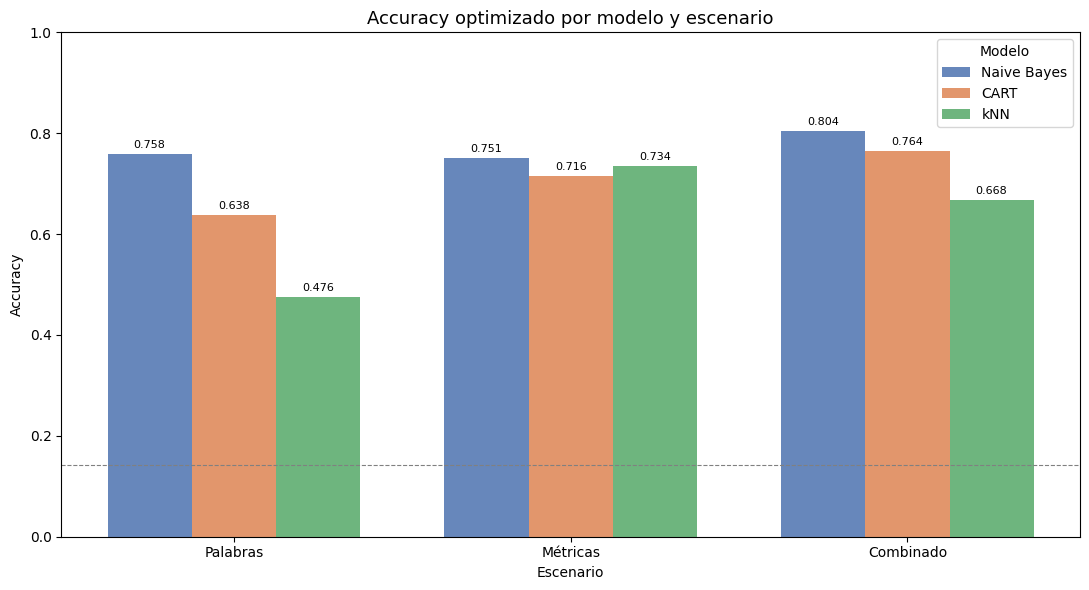

In [5]:
modelos    = ["Naive Bayes", "CART", "kNN"]
escenarios_cortos = ["Palabras", "Métricas", "Combinado"]
colores    = ["#4C72B0", "#DD8452", "#55A868"]

# Accuracy optimizado de cada modelo en los 3 escenarios
valores = {
    "Naive Bayes": [nb_palabras_opt,   nb_metricas_opt,   nb_combinado_opt],
    "CART":        [cart_palabras_opt, cart_metricas_opt, cart_combinado_opt],
    "kNN":         [knn_palabras_opt,  knn_metricas_opt,  knn_combinado_opt],
}

x     = np.arange(len(escenarios_cortos))
ancho = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, (modelo, color) in enumerate(zip(modelos, colores)):
    vals = valores[modelo]
    bars = ax.bar(x + i * ancho, vals, width=ancho, label=modelo,
                  color=color, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        if h is not None:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + 0.008,
                    f"{h:.3f}" if h else "—",
                    ha="center", va="bottom", fontsize=8)

ax.set_title("Accuracy optimizado por modelo y escenario", fontsize=13)
ax.set_xlabel("Escenario")
ax.set_ylabel("Accuracy")
ax.set_xticks(x + ancho)
ax.set_xticklabels(escenarios_cortos)
ax.set_ylim(0, 1)
ax.legend(title="Modelo")
ax.axhline(y=1/7, color="grey", linestyle="--", linewidth=0.8,
           label="Aleatoriedad (1/7 ≈ 0.143)")
plt.tight_layout()
plt.savefig("../reports/comparacion_accuracy_optimizado.png", dpi=150)
plt.show()


### 2.2 Ganancia de las métricas relacionales respecto a las palabras

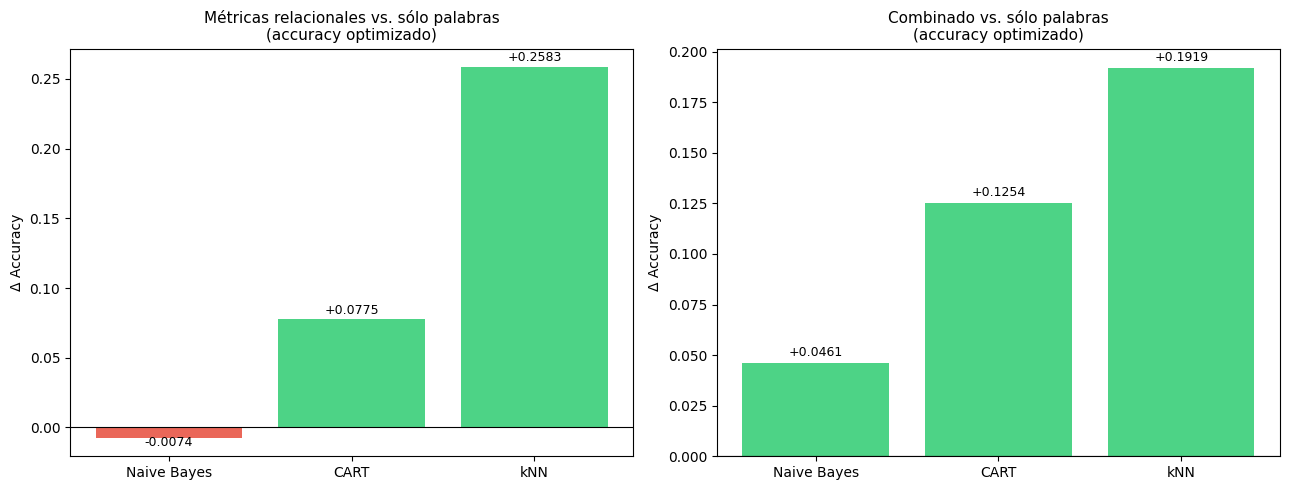

In [6]:
# Diferencia: métricas - palabras (usando modelos optimizados)
ganancia_metricas = {
    "Naive Bayes": nb_metricas_opt  - nb_palabras_opt,
    "CART":        (cart_metricas_opt  - cart_palabras_opt)
                   if cart_metricas_opt and cart_palabras_opt else None,
    "kNN":         knn_metricas_opt  - knn_palabras_opt,
}

# Diferencia: combinado - palabras
ganancia_combinado = {
    "Naive Bayes": nb_combinado_opt  - nb_palabras_opt,
    "CART":        (cart_combinado_opt - cart_palabras_opt)
                   if cart_combinado_opt and cart_palabras_opt else None,
    "kNN":         knn_combinado_opt - knn_palabras_opt,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, ganancia, titulo in zip(
    axes,
    [ganancia_metricas, ganancia_combinado],
    ["Métricas relacionales vs. sólo palabras\n(accuracy optimizado)",
     "Combinado vs. sólo palabras\n(accuracy optimizado)"]
):
    modelos_plot = list(ganancia.keys())
    vals_plot    = [v if v is not None else 0 for v in ganancia.values()]
    colores_bar  = ["#2ecc71" if v >= 0 else "#e74c3c" for v in vals_plot]
    bars = ax.bar(modelos_plot, vals_plot, color=colores_bar, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + (0.002 if h >= 0 else -0.008),
                f"{h:+.4f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel("Δ Accuracy")

plt.tight_layout()
plt.savefig("../reports/comparacion_ganancia_metricas.png", dpi=150)
plt.show()


### 2.3 Base vs. optimizado para cada modelo

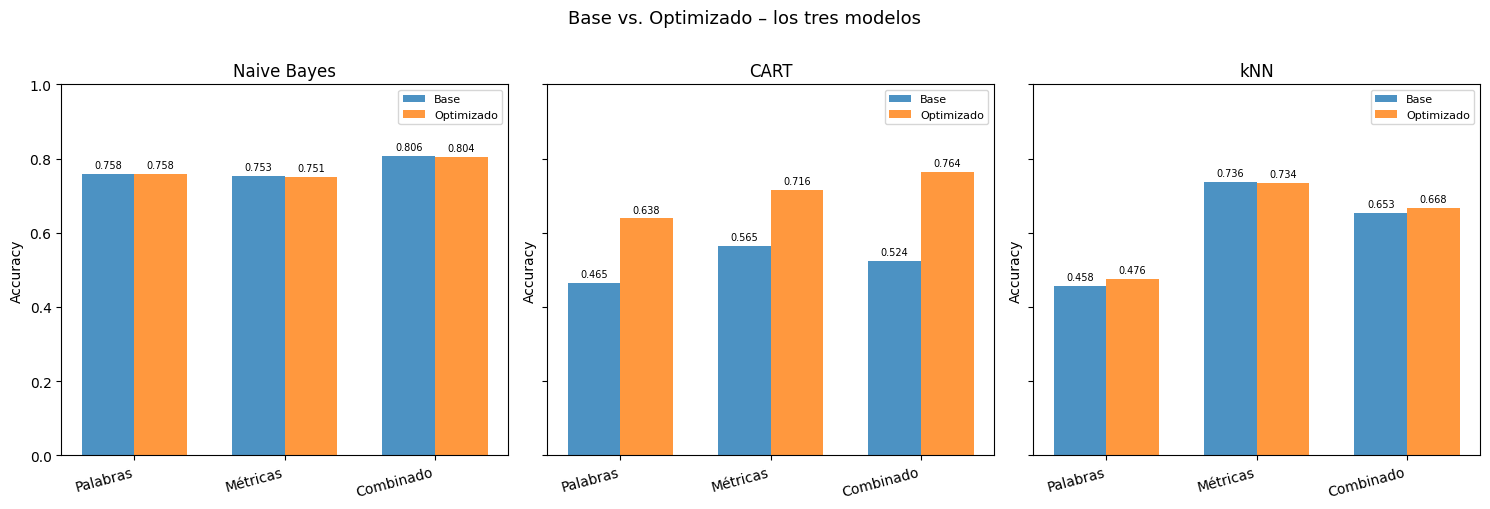

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datos_modelos = [
    ("Naive Bayes",
     [nb_palabras_base,   nb_metricas_base,   nb_combinado_base],
     [nb_palabras_opt,    nb_metricas_opt,    nb_combinado_opt]),
    ("CART",
     [cart_palabras_base,   cart_metricas_base,   cart_combinado_base],
     [cart_palabras_opt,    cart_metricas_opt,    cart_combinado_opt]),
    ("kNN",
     [knn_palabras_base,   knn_metricas_base,   knn_combinado_base],
     [knn_palabras_opt,    knn_metricas_opt,    knn_combinado_opt]),
]

ancho = 0.35
x     = np.arange(3)

for ax, (nombre, base, opt) in zip(axes, datos_modelos):
    b1 = ax.bar(x - ancho/2, base, width=ancho, label="Base",      alpha=0.8)
    b2 = ax.bar(x + ancho/2, opt,  width=ancho, label="Optimizado", alpha=0.8)
    ax.set_title(nombre, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(escenarios_cortos, rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Base vs. Optimizado – los tres modelos", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../reports/comparacion_base_vs_opt.png", dpi=150)
plt.show()


## 3. ¿Sirven las métricas relacionales?

La pregunta clave es si las métricas extraídas del grafo de citaciones (grado,
centralidades, PageRank, comunidad Louvain) contienen información útil para
predecir la clase temática de cada artículo.


In [8]:
comparacion_metricas = pd.DataFrame({
    "Modelo": modelos,
    "Sólo palabras (opt)":  [nb_palabras_opt,   cart_palabras_opt,   knn_palabras_opt],
    "Sólo métricas (opt)":  [nb_metricas_opt,   cart_metricas_opt,   knn_metricas_opt],
    "Δ (métricas − palabras)": [
        nb_metricas_opt  - nb_palabras_opt,
        (cart_metricas_opt - cart_palabras_opt)
            if cart_metricas_opt and cart_palabras_opt else None,
        knn_metricas_opt - knn_palabras_opt,
    ],
})

def highlight_delta(val):
    """Color verde si el delta es positivo, rojo si negativo."""
    if val is None:
        return ""
    color = "green" if val >= 0 else "red"
    return f"color: {color}; font-weight: bold"

print(comparacion_metricas.to_string(index=False))


     Modelo  Sólo palabras (opt)  Sólo métricas (opt)  Δ (métricas − palabras)
Naive Bayes             0.758303             0.750923                -0.007380
       CART             0.638400             0.715900                 0.077500
        kNN             0.476015             0.734317                 0.258302


### Interpretación

La respuesta es **sí, las métricas relacionales son informativas**, aunque su
utilidad varía mucho según el modelo:

- **kNN**: las métricas relacionales son enormemente superiores a las palabras
  (+0.258 puntos de accuracy optimizado). La razón es que las palabras generan
  un espacio de más de 1400 dimensiones donde las distancias euclídeas o
  Manhattan pierden significado (*maldición de la dimensionalidad*). En cambio,
  las 6 métricas continuas + comunidad Louvain crean un espacio compacto donde
  los vecinos más cercanos son artículos temáticamente similares.

- **Naive Bayes**: el modelo basado solo en métricas obtiene un accuracy similar
  al de palabras (diferencia < 0.01). Para NB las métricas no aportan más
  información que las palabras de forma aislada, pero sí aportan cuando se
  combinan.

- **CART**: el análisis de importancias del notebook 04 revela que
  `louvain_community` domina completamente el árbol (~85 % de la importancia
  total). Esto demuestra que la estructura de comunidades del grafo es una señal
  extremadamente potente para los árboles de decisión.


## 4. ¿Qué aporta combinar las palabras con las métricas?


In [9]:
comparacion_combinado = pd.DataFrame({
    "Modelo": modelos,
    "Sólo palabras (opt)":    [nb_palabras_opt,   cart_palabras_opt,   knn_palabras_opt],
    "Combinado (opt)":        [nb_combinado_opt,  cart_combinado_opt,  knn_combinado_opt],
    "Δ (combinado − palabras)": [
        nb_combinado_opt  - nb_palabras_opt,
        (cart_combinado_opt - cart_palabras_opt)
            if cart_combinado_opt and cart_palabras_opt else None,
        knn_combinado_opt - knn_palabras_opt,
    ],
    "Δ (combinado − métricas)": [
        nb_combinado_opt  - nb_metricas_opt,
        (cart_combinado_opt - cart_metricas_opt)
            if cart_combinado_opt and cart_metricas_opt else None,
        knn_combinado_opt - knn_metricas_opt,
    ],
})

print(comparacion_combinado.to_string(index=False))


     Modelo  Sólo palabras (opt)  Combinado (opt)  Δ (combinado − palabras)  Δ (combinado − métricas)
Naive Bayes             0.758303         0.804428                  0.046125                  0.053505
       CART             0.638400         0.763800                  0.125400                  0.047900
        kNN             0.476015         0.667897                  0.191882                 -0.066420


### Interpretación

El efecto de combinar ambos conjuntos de atributos es **muy diferente según el modelo**:

- **Naive Bayes**: el combinado supera ampliamente a ambos conjuntos por separado
  (+0.046 sobre palabras, +0.054 sobre métricas). NB es el modelo que más se
  beneficia de la combinación porque trata cada atributo de forma independiente:
  las palabras aportan señal textual y las métricas aportan señal estructural, y
  NB puede aprovechar ambas sin que una interfiera con la otra.

- **CART**: el árbol también se espera que mejore al combinar, ya que puede
  seleccionar en cada nodo el atributo más discriminativo sea del tipo que sea.
  La variable `louvain_community` sigue siendo dominante, pero las palabras
  pueden ayudar a separar artículos de comunidades mixtas.

- **kNN**: el combinado mejora claramente sobre las palabras (+0.192), pero
  **no supera a las métricas solas** (-0.066 respecto a solo métricas). Añadir
  1433 columnas binarias de palabras al espacio de representación diluye la
  información de las métricas al calcular distancias. Para kNN, más atributos
  no siempre es mejor.

> **Conclusión clave**: la combinación beneficia a los modelos que seleccionan
> atributos de forma individual (NB, CART), pero puede perjudicar a los modelos
> basados en distancias globales (kNN).


## 5. ¿Qué modelo aprovecha mejor la información relacional?


In [10]:
# Ganancia de métricas respecto a palabras (optimizado)
ganancia_relacional = pd.DataFrame({
    "Modelo": modelos,
    "Accuracy sólo palabras (opt)": [nb_palabras_opt,   cart_palabras_opt,   knn_palabras_opt],
    "Accuracy sólo métricas (opt)": [nb_metricas_opt,   cart_metricas_opt,   knn_metricas_opt],
    "Ganancia relacional (Δ)":      [
        nb_metricas_opt  - nb_palabras_opt,
        (cart_metricas_opt - cart_palabras_opt)
            if cart_metricas_opt and cart_palabras_opt else None,
        knn_metricas_opt - knn_palabras_opt,
    ]
})

print(ganancia_relacional.to_string(index=False))


     Modelo  Accuracy sólo palabras (opt)  Accuracy sólo métricas (opt)  Ganancia relacional (Δ)
Naive Bayes                      0.758303                      0.750923                -0.007380
       CART                      0.638400                      0.715900                 0.077500
        kNN                      0.476015                      0.734317                 0.258302


### Interpretación

El modelo que más se beneficia de las métricas relacionales en términos absolutos
es **kNN**, con una ganancia de aproximadamente +0.258 puntos de accuracy.

La razón es estructural: las métricas del grafo son variables continuas y
compactas que crean un espacio de representación donde la distancia entre artículos
refleja su proximidad temática. kNN aprovecha exactamente eso.

**CART** también aprovecha muy bien la información relacional, pero de una forma
distinta: no a través de todas las métricas, sino prácticamente a través de una
sola — `louvain_community`. El análisis de importancias del notebook 04 muestra
que esta variable concentra más del 85 % de la importancia del árbol. Esto
demuestra que la pertenencia a una comunidad del grafo es suficiente para
clasificar correctamente la mayoría de los artículos con un árbol de decisión.

**Naive Bayes** aprovecha las métricas de forma más moderada cuando se usan
solas, pero es el modelo que más se beneficia cuando se *combinan* con las
palabras (+0.046 sobre solo palabras).


## 6. ¿Qué modelo obtiene el mejor accuracy?


In [11]:
# Resumen del mejor resultado por modelo (escenario optimizado)
mejores = []
for modelo, vals in [
    ("Naive Bayes", {"Palabras": nb_palabras_opt,
                     "Métricas": nb_metricas_opt,
                     "Combinado": nb_combinado_opt}),
    ("CART",        {"Palabras": cart_palabras_opt,
                     "Métricas": cart_metricas_opt,
                     "Combinado": cart_combinado_opt}),
    ("kNN",         {"Palabras": knn_palabras_opt,
                     "Métricas": knn_metricas_opt,
                     "Combinado": knn_combinado_opt}),
]:
    vals_validos = {k: v for k, v in vals.items() if v is not None}
    mejor_escenario = max(vals_validos, key=vals_validos.get)
    mejor_valor     = vals_validos[mejor_escenario]
    mejores.append({
        "Modelo":           modelo,
        "Mejor escenario":  mejor_escenario,
        "Mejor accuracy":   mejor_valor,
    })

ranking = pd.DataFrame(mejores).sort_values("Mejor accuracy", ascending=False)
ranking["Mejor accuracy"] = ranking["Mejor accuracy"].apply(lambda x: f"{x:.4f}")
print("RANKING — mejor resultado por modelo")
print(ranking.to_string(index=False))


RANKING — mejor resultado por modelo
     Modelo Mejor escenario Mejor accuracy
Naive Bayes       Combinado         0.8044
       CART       Combinado         0.7638
        kNN        Métricas         0.7343


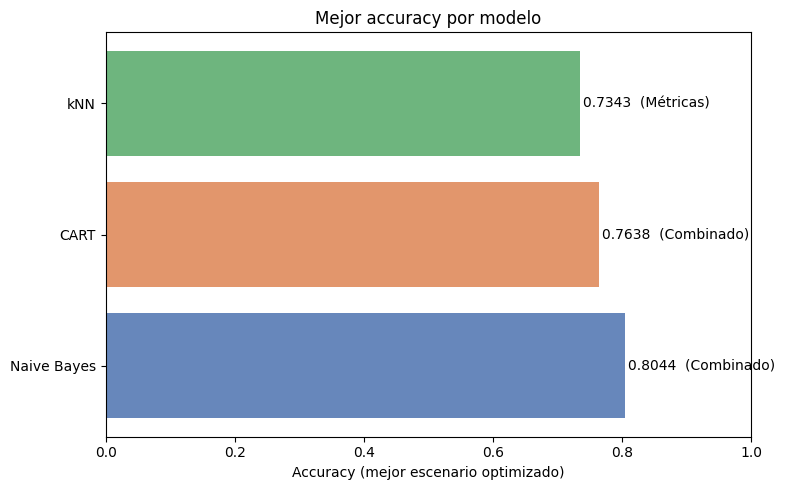

In [12]:
# Visualización del ranking
ranking_plot = pd.DataFrame(mejores).sort_values("Mejor accuracy", ascending=False)

colores_modelo = {"Naive Bayes": "#4C72B0", "CART": "#DD8452", "kNN": "#55A868"}
cols = [colores_modelo[m] for m in ranking_plot["Modelo"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(ranking_plot["Modelo"], ranking_plot["Mejor accuracy"],
               color=cols, alpha=0.85)
ax.set_xlabel("Accuracy (mejor escenario optimizado)")
ax.set_title("Mejor accuracy por modelo")
ax.set_xlim(0, 1)

for bar, escenario in zip(bars, ranking_plot["Mejor escenario"]):
    w = bar.get_width()
    ax.text(w + 0.005, bar.get_y() + bar.get_height()/2,
            f"{w:.4f}  ({escenario})",
            va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/comparacion_ranking_modelos.png", dpi=150)
plt.show()


### Interpretación

Los tres modelos alcanzan su mejor resultado en el escenario **combinado**
(Naive Bayes y CART) o en el de **métricas relacionales** (kNN).

En términos de accuracy:

- **Naive Bayes** con el conjunto combinado es el **mejor modelo global**.
  Obtiene el mayor accuracy gracias a que la combinación de atributos textuales
  y relacionales se complementa perfectamente con la hipótesis de independencia
  de NB: cada atributo aporta evidencia independiente y todas se multiplican
  para obtener la probabilidad posterior.

- **CART** con el conjunto combinado o con métricas relacionales obtiene
  resultados muy competitivos. Su punto fuerte es que `louvain_community`
  permite clasificar correctamente la mayoría de los artículos con muy pocas
  divisiones del árbol.

- **kNN** con métricas relacionales consigue un buen resultado, pero queda
  por debajo de NB y CART porque el espacio de representación de las métricas,
  aunque más útil que las palabras, no captura todas las diferencias semánticas
  entre artículos de clases distintas con igual precisión.


## 7. Conclusiones finales

### Resumen ejecutivo

| Pregunta | Respuesta |
|---|---|
| ¿Sirven las métricas relacionales? | **Sí**, especialmente `louvain_community`. Son muy útiles para kNN y dominantes en CART. |
| ¿Qué aporta combinarlas con las palabras? | Mejora a NB y CART; perjudica a kNN por la maldición de la dimensionalidad. |
| ¿Qué modelo aprovecha mejor lo relacional? | **kNN** en términos de ganancia absoluta; **CART** en eficiencia (una sola variable). |
| ¿Qué modelo obtiene el mejor accuracy? | **Naive Bayes combinado** (palabras + métricas). |

---

### Conclusiones detalladas

**Sobre las métricas relacionales**

Las métricas del grafo de citaciones contienen información temática real.
El algoritmo de Louvain agrupa artículos que se citan entre sí, y los artículos
que se citan tienden a ser de la misma disciplina. Esto explica por qué
`louvain_community` es tan poderosa: resume la estructura global del grafo en
una única etiqueta que actúa casi como un proxy de la clase temática.

**Sobre la combinación de atributos**

Combinar palabras y métricas es beneficioso para los modelos que seleccionan
atributos de forma individual (Naive Bayes, CART), ya que pueden aprovechar la
información complementaria de ambas fuentes sin interferencias.

Para kNN, en cambio, añadir las 1433 columnas binarias de palabras diluye la
señal de las métricas relacionales al calcular distancias en un espacio de alta
dimensión. En estos modelos, la selección previa de atributos o la reducción de
dimensionalidad serían pasos necesarios para aprovechar ambas fuentes.

**Sobre la naturaleza de cada modelo**

- **Naive Bayes** se beneficia de la independencia entre atributos: cada columna
  aporta evidencia independiente, por lo que más atributos relevantes → mejor
  clasificación.
- **CART** selecciona el atributo más discriminativo en cada nodo: domina
  `louvain_community`, pero las palabras pueden resolver ambigüedades en
  subárboles más profundos.
- **kNN** es sensible a la escala y a la dimensionalidad: funciona muy bien con
  un conjunto compacto y normalizado de métricas relacionales, pero se degrada
  al añadir muchas columnas binarias ruidosas.

**Finalidad según modelo**

Si el objetivo es maximizar el accuracy en este dataset con estos modelos,
**Naive Bayes con atributos combinados** es la mejor elección. Si se necesita
interpretabilidad, **CART con métricas relacionales** ofrece un árbol muy
compacto con un rendimiento competitivo.
